In [91]:
import pandas as pd

df = pd.read_excel("../data/cleandata.xlsx")

PermissionError: [Errno 13] Permission denied: '../data/cleandata.xlsx'

In [88]:
policy_df = pd.read_csv(
    "../data/policy_table.csv"
)

policy_df.head()# move to after state_id

,State,Best_Action
0,0.0-0.0-0.1,Do Nothing
1,0.0-0.0-0.2,Do Nothing
2,0.0-0.0-0.3,Do Nothing
3,0.0-0.0-0.4,Do Nothing
4,0.0-0.0-0.5,Do Nothing


In [78]:
def power_category(power):

    if power < 60:
        return "Low"

    elif power <= 100:
        return "Medium"

    else:
        return "High"

In [ ]:
def temp_category(temp):

    if temp < 12:
        return "Cool"

    elif temp <= 18:
        return "Moderate"

    else:
        return "Hot"

In [ ]:
def occupancy_status(occ):

    if occ == 0:
        return "Empty"

    elif 1 <= occ <= 5:
        return "Low"

    elif 6 <= occ <= 20:
        return "Medium"

    else:
        return "High"

In [ ]:
def extract_hour(hour):

    if 0 <= hour <= 3:
        return "Late Night"

    elif 4 <= hour <= 6:
        return "Early Morning"

    elif 7 <= hour <= 11:
        return "Morning"

    elif 12 <= hour <= 15:
        return "Afternoon"

    elif 16 <= hour <= 19:
        return "Evening"

    else:
        return "Night"

In [80]:
df["date"] = pd.to_datetime(df["date"])

df["Hour"] = df["date"].dt.hour

df["Power Category"] = df["Power Consumption"].apply(power_category)

df["Temperature Category"] = df["Outdoor Temperature"].apply(temp_category)

df["Occupancy Status"] = df["Occupancy"].apply(occupancy_status)

df["Time of Day"] = df["Hour"].apply(extract_hour)

df.head()

,date,Power Consumption,Outdoor Temperature,Occupancy,Power_Norm,Occupancy_Norm,Temperature_Norm,Power_State,Occupancy_State,Temperature_State,...,State_y,Best_Action_y,State,Best_Action,Agent_Decision,Hour,Power Category,Temperature Category,Occupancy Status,Time of Day
0,2018-05-22 00:00:00,71.98,15.72,1,0.383355,0.008197,0.414912,0.4,0.0,0.4,...,0.4-0.0-0.4,Reduce HVAC,0.4-0.0-0.4,Reduce HVAC,State: 0.4-0.0-0.4 | Action: Reduce HVAC,0,Medium,Moderate,Low,Late Night
1,2018-05-22 00:15:00,71.00,15.37,1,0.377780,0.008197,0.400168,0.4,0.0,0.4,...,0.4-0.0-0.4,Reduce HVAC,0.4-0.0-0.4,Reduce HVAC,State: 0.4-0.0-0.4 | Action: Reduce HVAC,0,Medium,Moderate,Low,Late Night
2,2018-05-22 00:30:00,65.20,15.27,0,0.344786,0.000000,0.395956,0.3,0.0,0.4,...,0.3-0.0-0.4,Reduce HVAC,0.3-0.0-0.4,Reduce HVAC,State: 0.3-0.0-0.4 | Action: Reduce HVAC,0,Medium,Moderate,Empty,Late Night
3,2018-05-22 00:45:00,95.90,16.03,0,0.519427,0.000000,0.427970,0.5,0.0,0.4,...,0.5-0.0-0.4,Reduce HVAC,0.5-0.0-0.4,Reduce HVAC,State: 0.5-0.0-0.4 | Action: Reduce HVAC,0,Medium,Moderate,Empty,Late Night
4,2018-05-22 01:00:00,43.60,15.28,0,0.221913,0.000000,0.396377,0.2,0.0,0.4,...,0.2-0.0-0.4,Reduce HVAC,0.2-0.0-0.4,Reduce HVAC,State: 0.2-0.0-0.4 | Action: Reduce HVAC,1,Low,Moderate,Empty,Late Night


In [ ]:
print(power_category(80))
print(temp_category(15))
print(occupancy_status(0))
print(extract_hour(2))

Medium
Moderate
Empty
Late Night


In [ ]:
df["date"] = pd.to_datetime(df["date"])

df["Hour"] = df["date"].dt.hour

df["Power Category"] = df["Power Consumption"].apply(power_category)

df["Temperature Category"] = df["Outdoor Temperature"].apply(temp_category)

df["Occupancy Status"] = df["Occupancy"].apply(occupancy_status)

df["Time of Day"] = df["Hour"].apply(extract_hour)

df.head()

,date,Power Consumption,Outdoor Temperature,Occupancy,Hour,Power Category,Temperature Category,Occupancy Status,Time of Day
0,2018-05-22 00:00:00,71.98,15.72,1,0,Medium,Moderate,Low,Late Night
1,2018-05-22 00:15:00,71.00,15.37,1,0,Medium,Moderate,Low,Late Night
2,2018-05-22 00:30:00,65.20,15.27,0,0,Medium,Moderate,Empty,Late Night
3,2018-05-22 00:45:00,95.90,16.03,0,0,Medium,Moderate,Empty,Late Night
4,2018-05-22 01:00:00,43.60,15.28,0,1,Low,Moderate,Empty,Late Night


In [81]:
df["Power_Norm"] = (
    df["Power Consumption"]
    - df["Power Consumption"].min()
) / (
    df["Power Consumption"].max()
    - df["Power Consumption"].min()
)

df["Occupancy_Norm"] = (
    df["Occupancy"]
    - df["Occupancy"].min()
) / (
    df["Occupancy"].max()
    - df["Occupancy"].min()
)

df["Temperature_Norm"] = (
    df["Outdoor Temperature"]
    - df["Outdoor Temperature"].min()
) / (
    df["Outdoor Temperature"].max()
    - df["Outdoor Temperature"].min()
)

In [ ]:
# ==========================
# MEMORY MODULE
# ==========================

hourly_power_memory = (
    df.groupby("Hour")
      ["Power Consumption"]
      .mean()
)

hourly_occupancy_memory = (
    df.groupby("Hour")
      ["Occupancy"]
      .mean()
)

hourly_temperature_memory = (
    df.groupby("Hour")
      ["Outdoor Temperature"]
      .mean()
)

In [82]:
df["Power_State"] = (
    (df["Power_Norm"] * 10)
    .round()
    / 10
)

df["Occupancy_State"] = (
    (df["Occupancy_Norm"] * 10)
    .round()
    / 10
)

df["Temperature_State"] = (
    (df["Temperature_Norm"] * 10)
    .round()
    / 10
)

In [83]:
df["State_ID"] = (
    df["Power_State"].astype(str)
    + "-"
    + df["Occupancy_State"].astype(str)
    + "-"
    + df["Temperature_State"].astype(str)
)

In [84]:
df[
    [
        "Power_State",
        "Occupancy_State",
        "Temperature_State",
        "State_ID"
    ]
].head()

,Power_State,Occupancy_State,Temperature_State,State_ID
0,0.4,0.0,0.4,0.4-0.0-0.4
1,0.4,0.0,0.4,0.4-0.0-0.4
2,0.3,0.0,0.4,0.3-0.0-0.4
3,0.5,0.0,0.4,0.5-0.0-0.4
4,0.2,0.0,0.4,0.2-0.0-0.4


In [ ]:
def get_historical_context(hour):

    expected_power = hourly_power_memory[hour]

    expected_occupancy = hourly_occupancy_memory[hour]

    expected_temperature = hourly_temperature_memory[hour]

    return {
        "expected_power": round(expected_power, 2),
        "expected_occupancy": round(expected_occupancy, 2),
        "expected_temperature": round(expected_temperature, 2)
    }

In [ ]:
sample = df.iloc[0]

hour = sample["Hour"]

memory = get_historical_context(hour)

print(memory)

{'expected_power': np.float64(79.49), 'expected_occupancy': np.float64(2.54), 'expected_temperature': np.float64(16.0)}


In [85]:
current_power = sample["Power Consumption"]

historical_power = memory["expected_power"]

power_deviation = current_power - historical_power

print(power_deviation)

-7.5100003619999995


In [ ]:
goal = "Minimize unnecessary energy consumption"

print(goal)

Minimize unnecessary energy consumption


In [ ]:
actions = [
    "Do Nothing",
    "Reduce HVAC Usage",
    "Check Idle Equipment",
    "Reduce Lighting"
]

print(actions)

['Do Nothing', 'Reduce HVAC Usage', 'Check Idle Equipment', 'Reduce Lighting']


In [ ]:
def evaluate_action(
        action,
        power_deviation,
        occupancy):

    energy_score = 0
    comfort_score = 0

    # -------------------
    # Energy Saving Score
    # -------------------

    if action == "Do Nothing":

        energy_score = max(0, 5 - abs(power_deviation)/10)

    elif action == "Reduce HVAC Usage":

        energy_score = max(0, power_deviation/5)

    elif action == "Check Idle Equipment":

        energy_score = max(0, power_deviation/4)

    elif action == "Reduce Lighting":

        energy_score = max(0, power_deviation/6)

    # -------------------
    # Comfort Score
    # -------------------

    if action == "Do Nothing":

        comfort_score = 10

    elif action == "Reduce HVAC Usage":

        comfort_score = max(0, 10 - occupancy/5)

    elif action == "Check Idle Equipment":

        comfort_score = 9

    elif action == "Reduce Lighting":

        comfort_score = max(0, 10 - occupancy/10)

    reward = energy_score - (10 - comfort_score)
    
    utility = reward

    return {
    "energy_score": round(energy_score,2),
    "comfort_score": round(comfort_score,2),
    "reward": round(reward,2),
    "utility": round(utility,2)
}

In [92]:
for action in actions:

    result = evaluate_action(
        action,
        power_deviation,
        occupancy
    )

    print(action)
    print(result)
    print()

NameError: name 'occupancy' is not defined

In [93]:
selected_actions = []
utilities = []
reasons = []
rewards = []

for index, row in df.iterrows():

    memory = get_historical_context(row["Hour"])

    power_deviation = (
        row["Power Consumption"]
        - memory["expected_power"]
    )

    occupancy = row["Occupancy"]

    best_action = None
    best_utility = -1

    for action in actions:

        result = evaluate_action(
            action,
            power_deviation,
            occupancy
        )

        utility = result["utility"]

        if utility > best_utility:

            best_utility = utility

            best_action = action
            best_reward = result["reward"]
          

            # A* = argmax_a U(a)

    selected_actions.append(best_action)
    utilities.append(best_utility)
    rewards.append(best_reward)

    if best_action == "Do Nothing":
        reason = "Current consumption is close to historical expectation."

    elif best_action == "Check Idle Equipment":
        reason = "Power usage is significantly above expected levels."

    elif best_action == "Reduce HVAC Usage":
        reason = "High power consumption detected during occupied hours."

    elif best_action == "Reduce Lighting":
        reason = "Low occupancy suggests lighting demand can be reduced."
    
    reasons.append(reason)

    

df["Selected Action"] = selected_actions

df["Reason"] = reasons

df["Utility Score"] = utilities

df["Reward"] = rewards



In [ ]:
df[[
    "Selected Action",
    "Reward"
]].head()

In [ ]:
print(len(df))
print(len(selected_actions))
print(len(reasons))
print(len(utilities))
print(len(rewards))

21262
21262
21262
21262
21262


In [ ]:
df["Confidence"] = (
    df["Reward"]
    /
    df["Reward"].max()
) * 100

In [ ]:
df[[
    "Selected Action",
    "Reward",
    "Confidence"
]].head(10)

,Selected Action,Reward,Confidence
0,Do Nothing,4.25,18.624014
1,Do Nothing,4.15,18.185802
2,Do Nothing,3.57,15.644172
3,Do Nothing,3.36,14.723926
4,Do Nothing,2.18,9.553024
5,Do Nothing,1.87,8.194566
6,Do Nothing,2.86,12.532866
7,Do Nothing,4.74,20.771253
8,Do Nothing,1.35,5.915863
9,Do Nothing,3.01,13.190184


In [ ]:
df["Goal"] = (
    "Minimize energy consumption while maintaining comfort"
)

In [ ]:
df["Current State"] = (
    df["Power Category"] + ", " +
    df["Occupancy Status"] + ", " +
    df["Time of Day"]
)

In [ ]:
historical_contexts = []

for index, row in df.iterrows():

    memory = get_historical_context(row["Hour"])

    context = (
        f"Expected Power: "
        f"{round(memory['expected_power'],1)}"
    )

    historical_contexts.append(context)

In [ ]:
df["Historical Context"] = historical_contexts

In [ ]:
#checking
df["Agent Report"] = (
    "Current State: " + df["Current State"] +
    "\n\nHistorical Context: " + df["Historical Context"] +
    "\n\nGoal: " + df["Goal"] +
    "\n\nSelected Action: " + df["Selected Action"] +
    "\n\nReward: " + df["Reward"].round(2).astype(str) +
    "\n\nConfidence: " + df["Confidence"].round(1).astype(str) + "%" +
    "\n\nReason: " + df["Reason"]
)

In [ ]:
print(df["Agent Report"].iloc[0])

Current State: Medium, Low, Late Night

Historical Context: Expected Power: 79.5

Goal: Minimize energy consumption while maintaining comfort

Selected Action: Do Nothing

Reward: 4.25

Confidence: 18.6%

Reason: Current consumption is close to historical expectation.


In [ ]:
df["Agent Report"].sample(5).tolist()

['Current State: Medium, Medium, Late Night\n\nHistorical Context: Expected Power: 64.8\n\nGoal: Minimize energy consumption while maintaining comfort\n\nSelected Action: Do Nothing\n\nReward: 4.01\n\nConfidence: 17.6%\n\nReason: Current consumption is close to historical expectation.',
 'Current State: Low, Empty, Morning\n\nHistorical Context: Expected Power: 60.6\n\nGoal: Minimize energy consumption while maintaining comfort\n\nSelected Action: Do Nothing\n\nReward: 0.0\n\nConfidence: 0.0%\n\nReason: Current consumption is close to historical expectation.',
 'Current State: Medium, Low, Night\n\nHistorical Context: Expected Power: 85.1\n\nGoal: Minimize energy consumption while maintaining comfort\n\nSelected Action: Do Nothing\n\nReward: 4.98\n\nConfidence: 21.8%\n\nReason: Current consumption is close to historical expectation.',
 'Current State: High, Empty, Late Night\n\nHistorical Context: Expected Power: 79.5\n\nGoal: Minimize energy consumption while maintaining comfort\n\nSe

In [ ]:
df["Selected Action"].value_counts()

Selected Action
Do Nothing              18101
Check Idle Equipment     2889
Reduce HVAC Usage         272
Name: count, dtype: int64

In [ ]:
df.groupby("Selected Action")["Reward"].mean()

Selected Action
Check Idle Equipment    6.569270
Do Nothing              3.846758
Reduce HVAC Usage       3.651213
Name: Reward, dtype: float64

In [ ]:
df["Confidence"].describe()

count    21262.000000
mean        18.467052
std          7.579602
min          0.000000
25%         15.863278
50%         18.536372
75%         20.420684
max        100.000000
Name: Confidence, dtype: float64

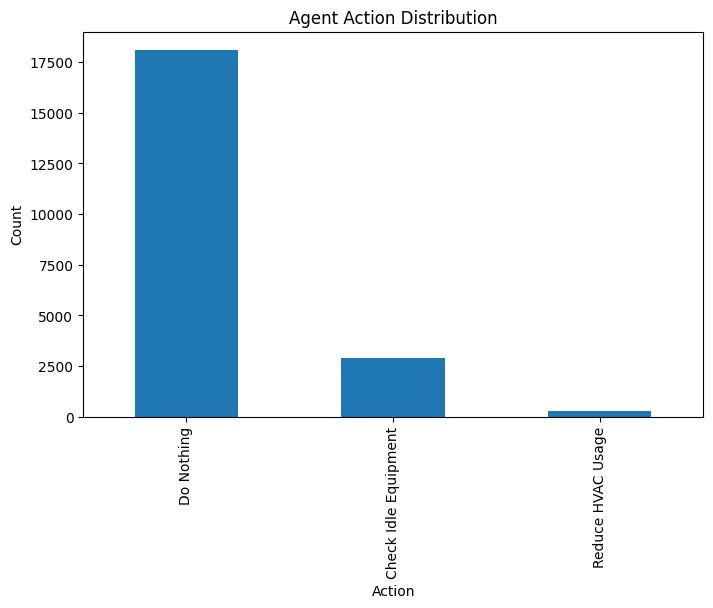

In [ ]:
import matplotlib.pyplot as plt

df["Selected Action"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Agent Action Distribution")
plt.xlabel("Action")
plt.ylabel("Count")

plt.show()

NameError: name 'plt' is not defined

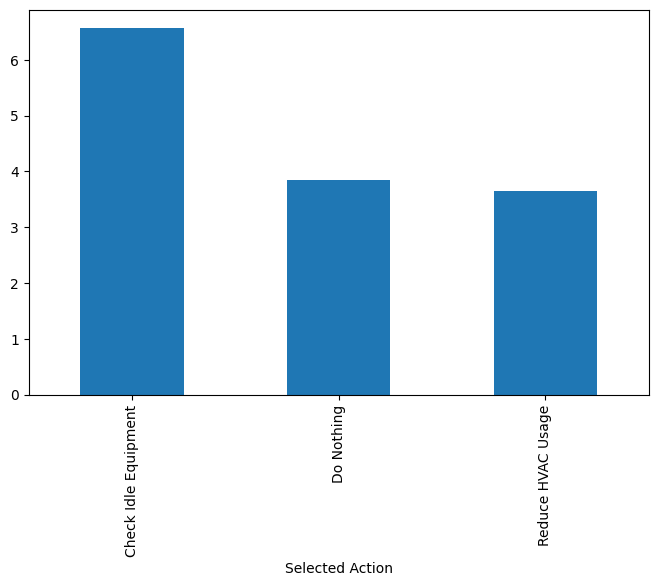

In [94]:
df.groupby("Selected Action")["Reward"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Reward per Action")
plt.ylabel("Reward")

plt.show()

In [96]:
import pandas as pd

df = pd.read_excel("../data/cleandata.xlsx")

df["Power_Norm"] = (
    df["Power Consumption"]
    - df["Power Consumption"].min()
) / (
    df["Power Consumption"].max()
    - df["Power Consumption"].min()
)

df["Occupancy_Norm"] = (
    df["Occupancy"]
    - df["Occupancy"].min()
) / (
    df["Occupancy"].max()
    - df["Occupancy"].min()
)

df["Temperature_Norm"] = (
    df["Outdoor Temperature"]
    - df["Outdoor Temperature"].min()
) / (
    df["Outdoor Temperature"].max()
    - df["Outdoor Temperature"].min()
)

df["Power_State"] = (
    (df["Power_Norm"] * 10)
    .round()
    / 10
)

df["Occupancy_State"] = (
    (df["Occupancy_Norm"] * 10)
    .round()
    / 10
)

df["Temperature_State"] = (
    (df["Temperature_Norm"] * 10)
    .round()
    / 10
)

PermissionError: [Errno 13] Permission denied: '../data/cleandata.xlsx'

In [ ]:
df["State_ID"] = (
    df["Power_State"].astype(str)
    + "-"
    + df["Occupancy_State"].astype(str)
    + "-"
    + df["Temperature_State"].astype(str)
)

df[
    [
        "Power_State",
        "Occupancy_State",
        "Temperature_State",
        "State_ID"
    ]
].head()

,Power_State,Occupancy_State,Temperature_State,State_ID
0,0.4,0.0,0.4,0.4-0.0-0.4
1,0.4,0.0,0.4,0.4-0.0-0.4
2,0.3,0.0,0.4,0.3-0.0-0.4
3,0.5,0.0,0.4,0.5-0.0-0.4
4,0.2,0.0,0.4,0.2-0.0-0.4


In [ ]:
print(policy_df.shape)

policy_df.head()

(337, 2)


,State,Best_Action
0,0.0-0.0-0.1,Do Nothing
1,0.0-0.0-0.2,Do Nothing
2,0.0-0.0-0.3,Do Nothing
3,0.0-0.0-0.4,Do Nothing
4,0.0-0.0-0.5,Do Nothing


In [ ]:
df = df.merge(
    policy_df,
    left_on="State_ID",
    right_on="State",
    how="left"
)

In [ ]:
df[
    [
        "State_ID","Best_Action"
    ]
].head(10)

,State_ID,Best_Action
0,0.4-0.0-0.4,Reduce HVAC
1,0.4-0.0-0.4,Reduce HVAC
2,0.3-0.0-0.4,Reduce HVAC
3,0.5-0.0-0.4,Reduce HVAC
4,0.2-0.0-0.4,Reduce HVAC
5,0.2-0.0-0.4,Reduce HVAC
6,0.3-0.0-0.4,Reduce HVAC
7,0.4-0.0-0.3,Reduce HVAC
8,0.2-0.0-0.3,Reduce HVAC
9,0.2-0.0-0.3,Reduce HVAC


In [ ]:
print(policy_df.columns.tolist())


['State', 'Best_Action']


In [ ]:
print(df.columns.tolist())

['date', 'Power Consumption', 'Outdoor Temperature', 'Occupancy']


In [ ]:
df[
    [
        "State_ID",
        "Best_Action_x"
    ]
].head(10)

,State_ID,Best_Action_x
0,0.4-0.0-0.4,Reduce HVAC
1,0.4-0.0-0.4,Reduce HVAC
2,0.3-0.0-0.4,Reduce HVAC
3,0.5-0.0-0.4,Reduce HVAC
4,0.2-0.0-0.4,Reduce HVAC
5,0.2-0.0-0.4,Reduce HVAC
6,0.3-0.0-0.4,Reduce HVAC
7,0.4-0.0-0.3,Reduce HVAC
8,0.2-0.0-0.3,Reduce HVAC
9,0.2-0.0-0.3,Reduce HVAC


In [ ]:
df = df.drop(
    columns=[
        "State_x",
        "Best_Action_x",
        "State_y",
        "Best_Action_y"
    ],
    errors="ignore"
)

In [ ]:
df = df.merge(
    policy_df,
    left_on="State_ID",
    right_on="State",
    how="left"
)

In [ ]:
print("State_ID" in df.columns)

print(df.columns.tolist())

print(policy_df.columns.tolist())

True
['date', 'Power Consumption', 'Outdoor Temperature', 'Occupancy', 'Power_Norm', 'Occupancy_Norm', 'Temperature_Norm', 'Power_State', 'Occupancy_State', 'Temperature_State', 'State_ID', 'State_x', 'Best_Action_x', 'State_y', 'Best_Action_y']
['State', 'Best_Action']


In [97]:
df = df.merge(
    policy_df,
    left_on="State_ID",
    right_on="State",
    how="left"
)

MergeError: Passing 'suffixes' which cause duplicate columns {'Best_Action_y', 'State_x', 'State_y', 'Best_Action_x'} is not allowed.

In [ ]:
df[
    [
        "State_ID",
        "Best_Action"
    ]
].head(10)

,State_ID,Best_Action
0,0.4-0.0-0.4,Reduce HVAC
1,0.4-0.0-0.4,Reduce HVAC
2,0.3-0.0-0.4,Reduce HVAC
3,0.5-0.0-0.4,Reduce HVAC
4,0.2-0.0-0.4,Reduce HVAC
5,0.2-0.0-0.4,Reduce HVAC
6,0.3-0.0-0.4,Reduce HVAC
7,0.4-0.0-0.3,Reduce HVAC
8,0.2-0.0-0.3,Reduce HVAC
9,0.2-0.0-0.3,Reduce HVAC


In [ ]:
print(
    "Missing Actions:",
    df["Best_Action"].isna().sum()
)

Missing Actions: 0


In [ ]:
print(
    df["Best_Action"]
    .value_counts()
)

Best_Action
Reduce HVAC        12753
Check Equipment     4015
Reduce Lighting     3614
Do Nothing           880
Name: count, dtype: int64


In [ ]:
#Converting action names to numbers for policytable
action_to_id = {

    "Do Nothing": 0,

    "Reduce HVAC": 1,

    "Check Equipment": 2,

    "Reduce Lighting": 3
}

In [113]:
#result-1
df["Agent_Decision"] = (
    "State: "
    + df["State_ID"]
    + " | Action: "
    + df["Best_Action"]
)
df[
    [
        "Agent_Decision"
    ]
].head(100)

,Agent_Decision
0,State: 0.4-0.0-0.4 | Action: Reduce HVAC
1,State: 0.4-0.0-0.4 | Action: Reduce HVAC
2,State: 0.3-0.0-0.4 | Action: Reduce HVAC
3,State: 0.5-0.0-0.4 | Action: Reduce HVAC
4,State: 0.2-0.0-0.4 | Action: Reduce HVAC
...,...
95,State: 0.4-0.1-0.2 | Action: Reduce HVAC
96,State: 0.4-0.0-0.2 | Action: Reduce HVAC
97,State: 0.2-0.0-0.2 | Action: Reduce HVAC
98,State: 0.3-0.0-0.2 | Action: Reduce HVAC


In [ ]:
sample_row = df.iloc[1]

sample_row

date                                        2018-05-22 00:15:00
Power Consumption                                          71.0
Outdoor Temperature                                       15.37
Occupancy                                                     1
Power_Norm                                              0.37778
Occupancy_Norm                                         0.008197
Temperature_Norm                                       0.400168
Power_State                                                 0.4
Occupancy_State                                             0.0
Temperature_State                                           0.4
State_ID                                            0.4-0.0-0.4
State_x                                             0.4-0.0-0.4
Best_Action_x                                       Reduce HVAC
State_y                                             0.4-0.0-0.4
Best_Action_y                                       Reduce HVAC
State                                   

In [109]:
current_state = (
    sample_row["Power_State"],
    sample_row["Occupancy_State"],
    sample_row["Temperature_State"]
)

print(current_state)

(np.float64(0.4), np.float64(0.0), np.float64(0.4))


In [111]:
results = []

for _, row in df.iterrows():

    current_state = (
        row["Power_State"],
        row["Occupancy_State"],
        row["Temperature_State"]
    )

    action_name = row["Best_Action"]

    action_id = action_to_id[action_name]

    next_state = get_next_state(
        current_state,
        action_id
    )

    power_before = current_state[0]

    power_after = next_state[0]

    if power_before > 0:

        energy_saving = (
            (power_before - power_after)
            / power_before
        ) * 100

    else:

        energy_saving = 0

    results.append(
        energy_saving
    )

In [114]:
print(
    "Average Energy Saving:",
    round(
        sum(results) / len(results),
        2
    ),
    "%"
)

Average Energy Saving: 53.58 %


In [118]:
def calculate_reward(
    state,
    next_state
):

    power_before = state[0]

    occupancy = state[1]

    temperature_before = state[2]

    power_after = next_state[0]

    temperature_after = next_state[2]

    energy_saving = (
        power_before
        - power_after
    )

    comfort_penalty = (
        occupancy
        *
        max(
            0,
            temperature_after
            - temperature_before
        )
    )

    reward = (
        energy_saving
        - comfort_penalty
    )

    return round(
        reward,
        2
    )

In [120]:
print(calculate_reward)

<function calculate_reward at 0x00000274FAD8D080>


In [122]:
print(df["Best_Action"].head())

0    Reduce HVAC
1    Reduce HVAC
2    Reduce HVAC
3    Reduce HVAC
4    Reduce HVAC
Name: Best_Action, dtype: str


In [124]:
sample_row = df.iloc[0]

action_name = sample_row[
    "Best_Action"
]

print(action_name)

Reduce HVAC


In [126]:
action_to_id = {

    "Do Nothing": 0,

    "Reduce HVAC": 1,

    "Check Equipment": 2,

    "Reduce Lighting": 3
}

In [128]:
action_id = action_to_id[
    action_name
]

print(action_id)

1


In [130]:
next_state = get_next_state(

    current_state,

    action_id

)

print(next_state)

(0.1, 0.0, 0.3)


In [132]:
reward = calculate_reward(

    current_state,

    next_state

)

print(reward)

0.3


In [134]:
power_before = current_state[0]

power_after = next_state[0]

energy_saving_percent = (
    (power_before - power_after)
    / power_before
) * 100

print(
    round(
        energy_saving_percent,
        2
    ),
    "%"
)

75.0 %


In [136]:
print("=" * 50)

print("INITIAL STATE")
print("Power State:", current_state[0])
print("Occupancy State:", current_state[1])
print("Temperature State:", current_state[2])

print()

print("RECOMMENDED ACTION")
print(action_name)

print()

print("PREDICTED NEXT STATE")
print("Power State:", next_state[0])
print("Occupancy State:", next_state[1])
print("Temperature State:", next_state[2])

print()

print("REWARD")
print(reward)

print()

print("PROJECTED ENERGY SAVING")
print

INITIAL STATE
Power State: 0.4
Occupancy State: 0.0
Temperature State: 0.2

RECOMMENDED ACTION
Reduce HVAC

PREDICTED NEXT STATE
Power State: 0.1
Occupancy State: 0.0
Temperature State: 0.3

REWARD
0.3

PROJECTED ENERGY SAVING


<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [138]:
df
action_to_id
get_next_state
calculate_reward

<function __main__.calculate_reward(state, next_state)>

In [144]:
results = []

for _, row in df.iterrows():

    current_state = (
        row["Power_State"],
        row["Occupancy_State"],
        row["Temperature_State"]
    )

    action_name = row["Best_Action"]

    action_id = action_to_id[
        action_name
    ]

    next_state = get_next_state(
        current_state,
        action_id
    )

    reward = calculate_reward(
        current_state,
        next_state
    )

    power_before = current_state[0]

    power_after = next_state[0]

    if power_before > 0:

        energy_saving_percent = (
            (power_before - power_after)
            / power_before
        ) * 100

    else:

        energy_saving_percent = 0

    results.append(
        [
            row["State_ID"],
            action_name,
            next_state,
            reward,
            round(
                energy_saving_percent,
                2
            )
        ]
    )

results_df = pd.DataFrame(
    results,
    columns=[
        "State_ID",
        "Best_Action",
        "Predicted_Next_State",
        "Reward",
        "Projected_Energy_Saving_%"
    ]
)

results_df.head(21000)

,State_ID,Best_Action,Predicted_Next_State,Reward,Projected_Energy_Saving_%
0,0.4-0.0-0.4,Reduce HVAC,"(0.1, 0.0, 0.5)",0.3,75.00
1,0.4-0.0-0.4,Reduce HVAC,"(0.1, 0.0, 0.5)",0.3,75.00
2,0.3-0.0-0.4,Reduce HVAC,"(0.1, 0.0, 0.5)",0.2,66.67
3,0.5-0.0-0.4,Reduce HVAC,"(0.2, 0.0, 0.5)",0.3,60.00
4,0.2-0.0-0.4,Reduce HVAC,"(0.1, 0.0, 0.5)",0.1,50.00
...,...,...,...,...,...
20995,0.4-0.0-0.2,Reduce HVAC,"(0.1, 0.0, 0.3)",0.3,75.00
20996,0.4-0.0-0.2,Reduce HVAC,"(0.1, 0.0, 0.3)",0.3,75.00
20997,0.4-0.0-0.2,Reduce HVAC,"(0.1, 0.0, 0.3)",0.3,75.00
20998,0.4-0.0-0.2,Reduce HVAC,"(0.1, 0.0, 0.3)",0.3,75.00


In [146]:
energy_savings = []

comfort_penalties = []

rewards = []

for _, row in df.iterrows():

    current_state = (
        row["Power_State"],
        row["Occupancy_State"],
        row["Temperature_State"]
    )

    action_name = row["Best_Action"]

    action_id = action_to_id[
        action_name
    ]

    next_state = get_next_state(
        current_state,
        action_id
    )

    power_before = current_state[0]

    power_after = next_state[0]

    energy_saving = (
        power_before
        - power_after
    )

    temperature_before = current_state[2]

    temperature_after = next_state[2]

    comfort_penalty = (
        current_state[1]
        *
        max(
            0,
            temperature_after
            - temperature_before
        )
    )

    reward = calculate_reward(
        current_state,
        next_state
    )

    energy_savings.append(
        energy_saving
    )

    comfort_penalties.append(
        comfort_penalty
    )

    rewards.append(
        reward
    )

df["Energy_Saving"] = energy_savings

df["Comfort_Penalty"] = comfort_penalties

df["Reward"] = rewards

print(
    "Average Energy Saving:",
    round(
        df["Energy_Saving"].mean(),
        3
    )
)

print(
    "Average Comfort Penalty:",
    round(
        df["Comfort_Penalty"].mean(),
        3
    )
)

print(
    "Average Reward:",
    round(
        df["Reward"].mean(),
        3
    )
)

Average Energy Saving: 0.206
Average Comfort Penalty: 0.002
Average Reward: 0.204


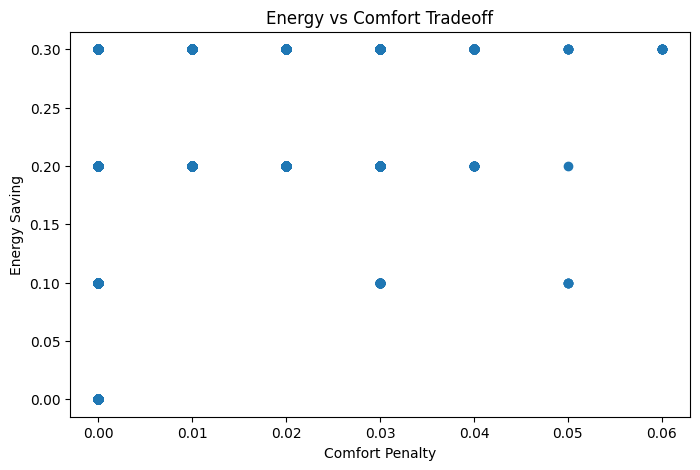

In [148]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    df["Comfort_Penalty"],
    df["Energy_Saving"]
)

plt.xlabel(
    "Comfort Penalty"
)

plt.ylabel(
    "Energy Saving"
)

plt.title(
    "Energy vs Comfort Tradeoff"
)

plt.show()

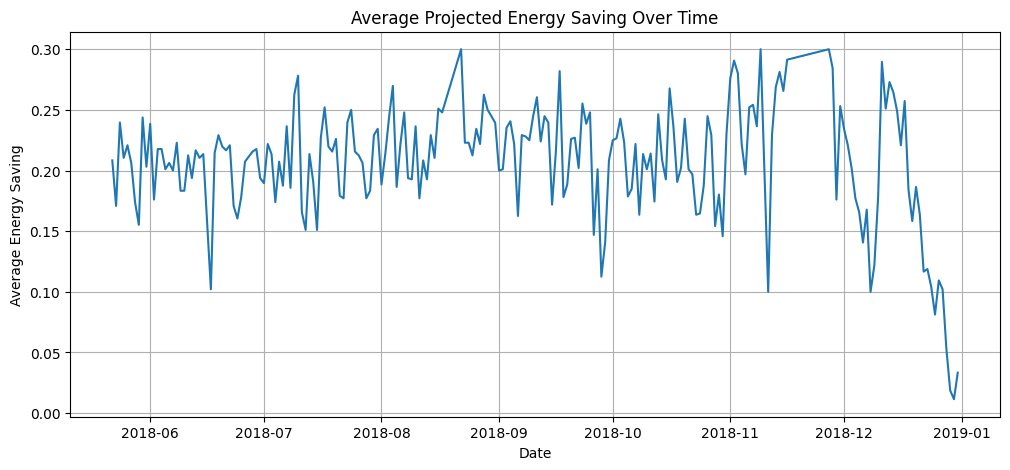

In [150]:
import matplotlib.pyplot as plt

daily_saving = (
    df.groupby(
        df["date"].dt.date
    )["Energy_Saving"]
    .mean()
)

plt.figure(figsize=(12,5))

daily_saving.plot()

plt.title(
    "Average Projected Energy Saving Over Time"
)

plt.xlabel("Date")

plt.ylabel(
    "Average Energy Saving"
)

plt.grid(True)

plt.show()

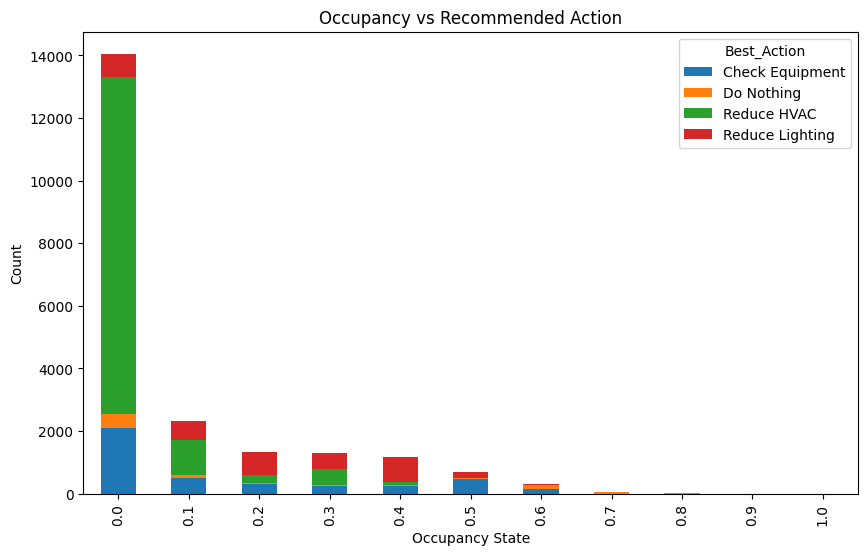

In [152]:
import pandas as pd
import matplotlib.pyplot as plt

action_counts = pd.crosstab(
    df["Occupancy_State"],
    df["Best_Action"]
)

action_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title(
    "Occupancy vs Recommended Action"
)

plt.xlabel(
    "Occupancy State"
)

plt.ylabel(
    "Count"
)

plt.show()

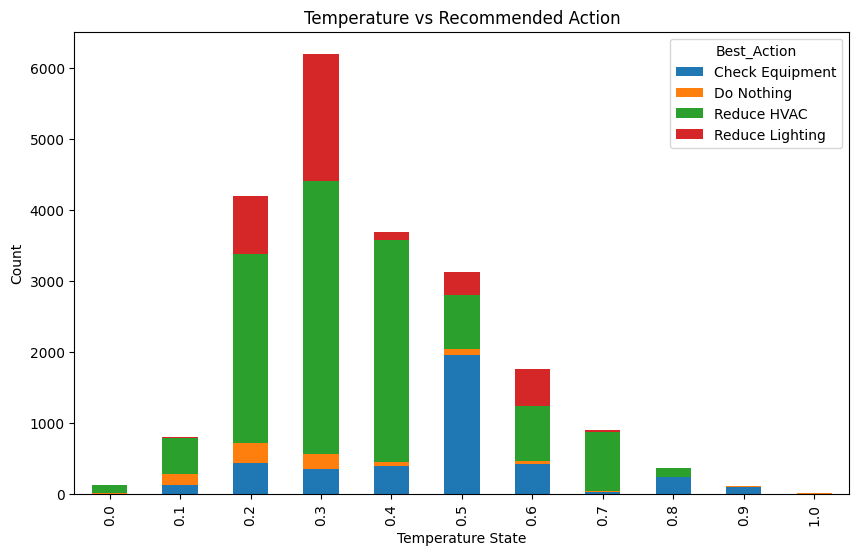

In [154]:
action_counts = pd.crosstab(
    df["Temperature_State"],
    df["Best_Action"]
)

action_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.title(
    "Temperature vs Recommended Action"
)

plt.xlabel(
    "Temperature State"
)

plt.ylabel(
    "Count"
)

plt.show()

In [157]:
tradeoff = df.groupby(
    "Best_Action"
).agg(
    {
        "Energy_Saving":"mean",
        "Comfort_Penalty":"mean"
    }
)

tradeoff

,Energy_Saving,Comfort_Penalty
Best_Action,,
Check Equipment,0.100000,0.000000
Do Nothing,0.000000,0.000000
Reduce HVAC,0.256042,0.002866
Reduce Lighting,0.200000,0.001522


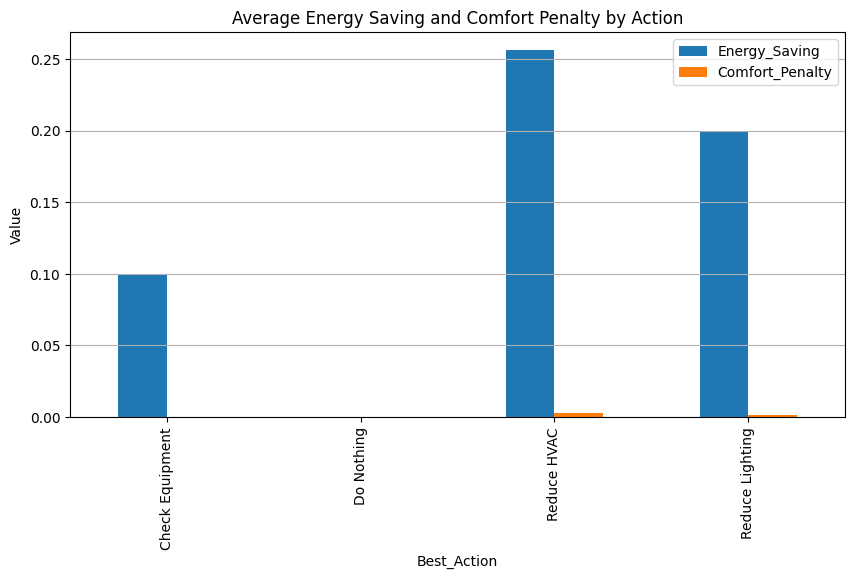

In [158]:
tradeoff.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Average Energy Saving and Comfort Penalty by Action"
)

plt.ylabel("Value")

plt.grid(axis="y")

plt.show()